## Importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

2025-01-04 18:08:20.374461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-04 18:08:20.479382: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1736042900.521172   22781 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1736042900.532923   22781 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-04 18:08:20.629491: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Data Preprocessing

In [3]:
!which python

/home/ayush/anaconda3/envs/tf-gpu/bin/python


In [67]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
print(tf.__version__)

2.18.0


In [5]:
### Training Image Preprocessing

In [6]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 70295 files belonging to 38 classes.


I0000 00:00:1736042966.546047   22781 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4158 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [7]:
###Validation Image Pre Processing

In [8]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    "valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [9]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [ ]:
for x, y in training_set:
    print(x, x.shape)
    print(y, y.shape)

In [22]:
##Building Models

In [11]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [12]:
models = Sequential()

In [13]:
##Building Convolution Layer

In [14]:
models.add(
    Conv2D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu",
        input_shape=[128, 128, 3],
    )
)
models.add(Conv2D(filters=32, kernel_size=3, activation="relu"))
models.add(MaxPool2D(pool_size=2, strides=2))

/home/ayush/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
models.add(Conv2D(filters=64, kernel_size=3, padding="same", activation="relu"))
models.add(Conv2D(filters=64, kernel_size=3, activation="relu"))
models.add(MaxPool2D(pool_size=2, strides=2))

In [16]:
models.add(Conv2D(filters=128, kernel_size=3, padding="same", activation="relu"))
models.add(Conv2D(filters=128, kernel_size=3, activation="relu"))
models.add(MaxPool2D(pool_size=2, strides=2))

In [17]:
models.add(Conv2D(filters=256, kernel_size=3, padding="same", activation="relu"))
models.add(Conv2D(filters=256, kernel_size=3, activation="relu"))
models.add(MaxPool2D(pool_size=2, strides=2))

In [18]:
models.add(Conv2D(filters=512, kernel_size=3, padding="same", activation="relu"))
models.add(Conv2D(filters=512, kernel_size=3, activation="relu"))
models.add(MaxPool2D(pool_size=2, strides=2))

In [19]:
models.add(Dropout(0.25))

In [20]:
models.add(Flatten())

In [21]:
models.add(Dense(units=1500, activation="relu"))

In [22]:
models.add(Dropout(0.40))

In [23]:
# Output layer
models.add(Dense(units=38, activation="softmax"))

In [24]:
##Compiling layers

In [25]:
models.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

In [26]:
models.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

### Training Model

In [27]:
training_history = models.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10


I0000 00:00:1736043407.182217   23013 service.cc:148] XLA service 0x7b18a8003150 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1736043407.182368   23013 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-01-04 18:16:47.229082: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1736043407.488244   23013 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-01-04 18:16:48.189896: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1960', 104 bytes spill stores, 104 bytes spill loads



   4/2197 ━━━━━━━━━━━━━━━━━━━━ 1:42 47ms/step - accuracy: 0.0254 - loss: 4.2938     

I0000 00:00:1736043414.904824   23013 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2195/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3888 - loss: 2.1667

2025-01-04 18:18:33.602149: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1960', 96 bytes spill stores, 96 bytes spill loads



2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3889 - loss: 2.1659

2025-01-04 18:18:39.954158: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 40 bytes spill stores, 40 bytes spill loads

2025-01-04 18:18:39.979501: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 100 bytes spill stores, 100 bytes spill loads

2025-01-04 18:18:40.023878: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 440 bytes spill stores, 440 bytes spill loads

2025-01-04 18:18:48.764750: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 76 bytes spill stores, 76 bytes spill loads



2197/2197 ━━━━━━━━━━━━━━━━━━━━ 124s 52ms/step - accuracy: 0.3890 - loss: 2.1656 - val_accuracy: 0.8190 - val_loss: 0.5650
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.8329 - loss: 0.5284 - val_accuracy: 0.9102 - val_loss: 0.2827
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9035 - loss: 0.2962 - val_accuracy: 0.9346 - val_loss: 0.2039
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9326 - loss: 0.2018 - val_accuracy: 0.9339 - val_loss: 0.2133
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9510 - loss: 0.1507 - val_accuracy: 0.9460 - val_loss: 0.1737
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9628 - loss: 0.1149 - val_accuracy: 0.9579 - val_loss: 0.1310
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 108s 49ms/step - accuracy: 0.9703 - loss: 0.0890 - val_accuracy: 0.9380 - val_loss: 0.2038
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 107s 49ms/step - accuracy: 0.9742 - lo

## Model Evaluation

In [28]:
train_loss, train_acc = models.evaluate(training_set)

2192/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9871 - loss: 0.0399

2025-01-04 18:40:43.985247: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 100 bytes spill stores, 100 bytes spill loads

2025-01-04 18:40:43.988507: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 52 bytes spill stores, 52 bytes spill loads

2025-01-04 18:40:44.030760: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_176', 400 bytes spill stores, 400 bytes spill loads



2197/2197 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.9871 - loss: 0.0399


In [29]:
print(train_loss, train_acc)

0.037202224135398865 0.9879934787750244


In [30]:
# Model on validation set
val_loss, val_acc = models.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9573 - loss: 0.1524


In [31]:
print(val_loss, val_acc)

0.14615057408809662 0.9587411880493164


## Saving Model

In [32]:
models.save("trained_model.h5")

In [33]:
models.save("trained_model.keras")

In [34]:
training_history.history

{'accuracy': [0.5934845805168152,
  0.8575005531311035,
  0.9123408198356628,
  0.9371505975723267,
  0.9540650248527527,
  0.9643644690513611,
  0.9697702527046204,
  0.9750622510910034,
  0.9795575737953186,
  0.9812362194061279],
 'loss': [1.3720566034317017,
  0.45001596212387085,
  0.27113330364227295,
  0.19013114273548126,
  0.14125730097293854,
  0.10995759069919586,
  0.09178444743156433,
  0.07509434223175049,
  0.06357918679714203,
  0.05757768452167511],
 'val_accuracy': [0.8190302848815918,
  0.9101980328559875,
  0.9345549941062927,
  0.9339289665222168,
  0.9459936022758484,
  0.9579444527626038,
  0.9379695057868958,
  0.914295494556427,
  0.9606191515922546,
  0.9587411880493164],
 'val_loss': [0.5650388598442078,
  0.2827306389808655,
  0.20393358170986176,
  0.21331621706485748,
  0.1737067997455597,
  0.13102813065052032,
  0.2038428783416748,
  0.29644790291786194,
  0.12950202822685242,
  0.14615054428577423]}

In [35]:
# Recording history in JSON format
import json

with open("training_hist.json", "w") as f:
    json.dump(training_history.history, f)

## Accuracy Visualization

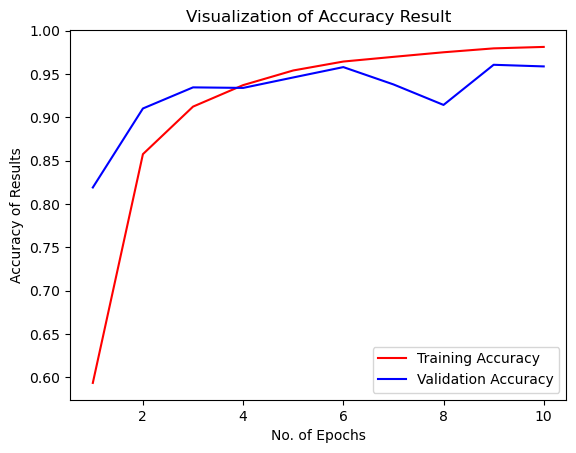

In [41]:
epochs = [i for i in range(1, 11)]
plt.plot(
    epochs, training_history.history["accuracy"], color="red", label="Training Accuracy"
)
plt.plot(
    epochs,
    training_history.history["val_accuracy"],
    color="blue",
    label="Validation Accuracy",
)
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy of Results")
plt.legend()
plt.title("Visualization of Accuracy Result")
plt.show()

### More metrics for evaluation

In [44]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [45]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True,
)

Found 17572 files belonging to 38 classes.


In [47]:
y_pred = models.predict(test_set)
y_pred, y_pred.shape

550/550 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step


(array([[9.9999952e-01, 4.1041486e-11, 5.1958595e-13, ..., 2.1494573e-17,
         3.5396829e-16, 5.3058948e-16],
        [9.9999905e-01, 5.8841223e-08, 3.4479959e-09, ..., 1.4844693e-14,
         1.6367711e-13, 1.5812660e-12],
        [1.0000000e+00, 3.2035823e-09, 2.0679916e-11, ..., 4.8575718e-17,
         1.2229102e-14, 4.2477449e-15],
        ...,
        [4.2814195e-15, 1.2303810e-17, 2.0536190e-13, ..., 1.6893453e-16,
         4.4914207e-18, 1.0000000e+00],
        [6.5544559e-13, 1.3042267e-14, 2.6244630e-11, ..., 1.1960344e-13,
         1.1015753e-14, 1.0000000e+00],
        [7.0890570e-17, 3.0628026e-17, 3.4924322e-16, ..., 3.9774310e-19,
         9.8281107e-17, 1.0000000e+00]], dtype=float32),
 (17572, 38))

In [48]:
predicted_categories = tf.argmax(y_pred, axis=1)

In [49]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [50]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

2025-01-04 19:15:29.474079: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [51]:
y_true = tf.argmax(true_categories, axis=1)
y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [57]:
from sklearn.metrics import classification_report, confusion_matrix

In [55]:
print(classification_report(y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.94      0.96       504
                                 Apple___Black_rot       0.98      0.97      0.98       497
                          Apple___Cedar_apple_rust       0.96      0.96      0.96       440
                                   Apple___healthy       0.87      0.99      0.93       502
                               Blueberry___healthy       0.98      0.98      0.98       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.95      0.97       421
                 Cherry_(including_sour)___healthy       0.93      1.00      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.92      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.96      0.

In [58]:
cn = confusion_matrix(y_true, predicted_categories)
cn.shape

(38, 38)

## Confusion Matrix Visualization

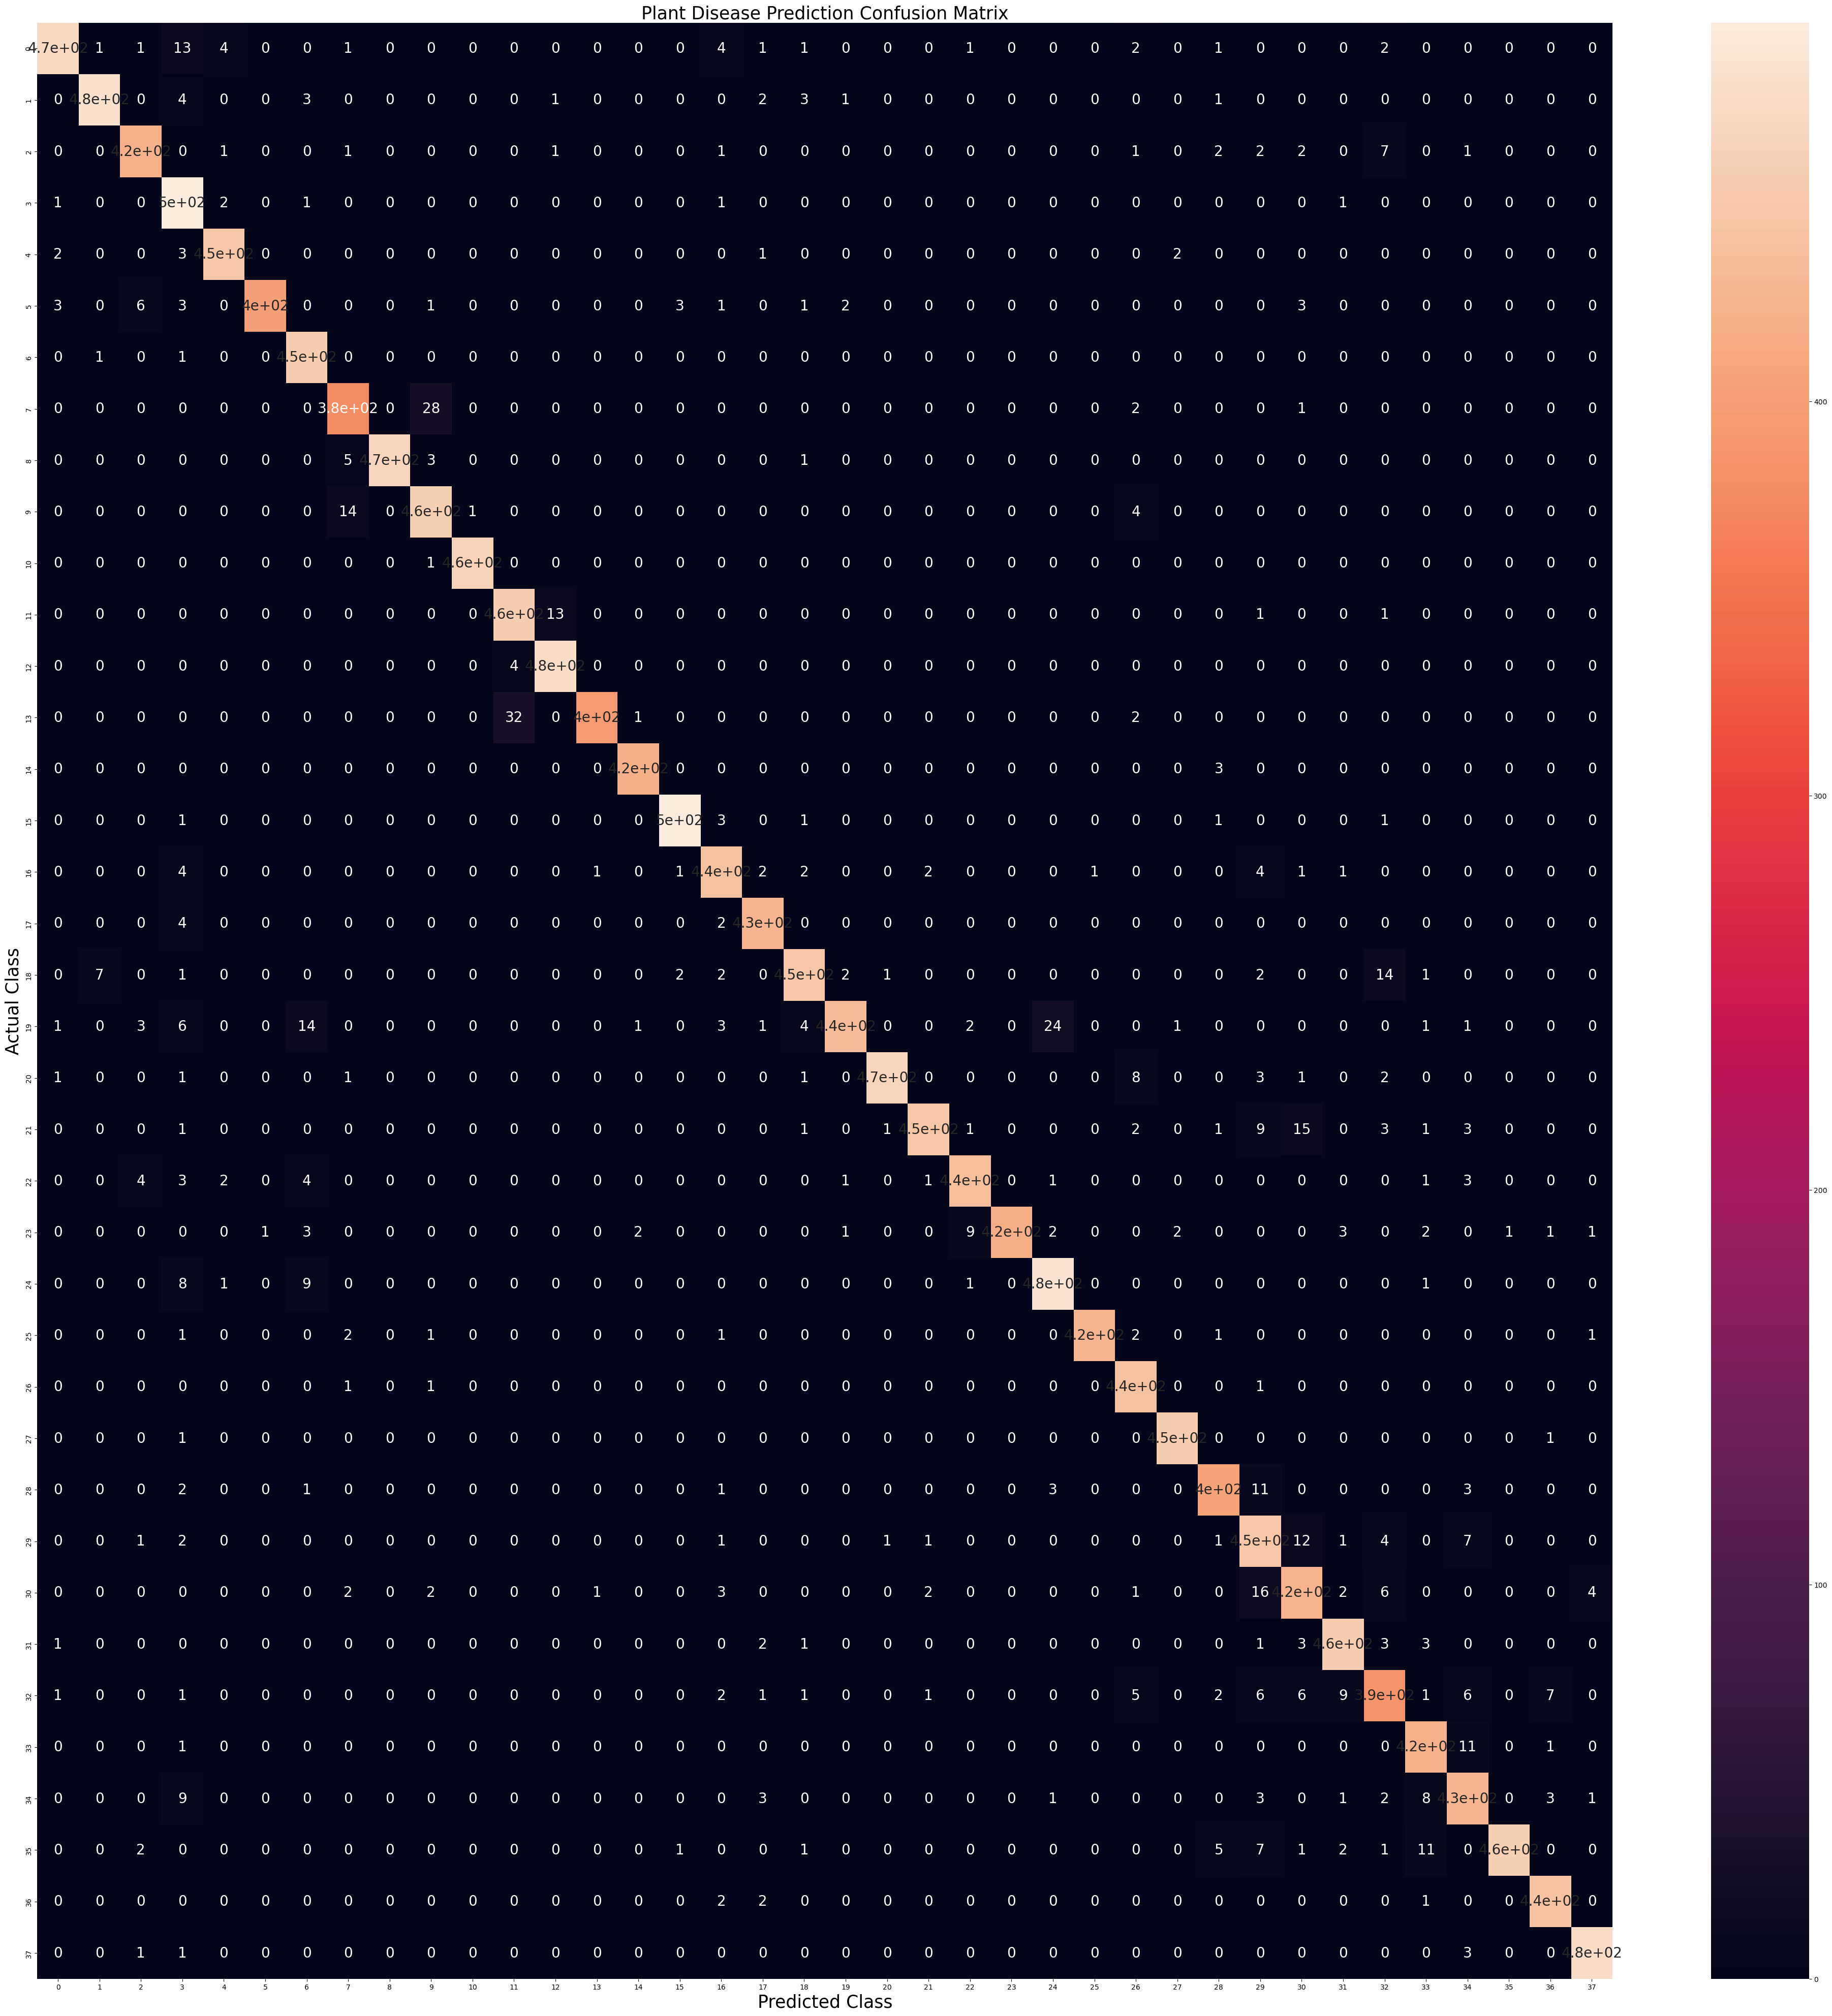

In [66]:
plt.figure(figsize=(50, 50))
sns.heatmap(cn, annot=True, annot_kws={"size": 20})
plt.xlabel("Predicted Class", fontsize=25)
plt.ylabel("Actual Class", fontsize=25)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=25)
plt.show()